# Complexity Pays Off?

## Project Overview

This project investigates whether more complex board games tend to receive higher user ratings and stronger market popularity.

Using a BoardGameGeek dataset, the analysis focuses on three core variables: **complexity**, **average rating**, and **owned users**. The main goal is to understand whether increasing complexity improves player evaluation, and whether it also helps a game become more popular in the market.

The project is designed as the analytical foundation for an **interactive data tool** that can help users:

- explore how complexity relates to ratings and popularity  
- compare different complexity levels more clearly  
- identify potential optimal levels when choosing board games  

The intended users are **casual players and board game buyers** who want a clearer balance between challenge, enjoyment, and popularity.

## Data Source and Key Variables

### Data Source

The dataset used in this project was downloaded from **Kaggle** and is based on data from **BoardGameGeek (BGG)**, one of the most widely used platforms for board game information, ratings, and user activity.

The dataset contains ranked board games with at least 30 user ratings. According to the dataset description, the data were collected in **February 2021** and last updated in **May 2022**.  
**Access date for this project:** 20 April 2026.

### Why This Dataset

This dataset is suitable for the project because it directly supports the main research question. It includes measures of:

- **complexity**, which reflects how difficult a game is to learn and play  
- **rating_average**, which reflects user evaluation  
- **owned_users**, which is used here as the main proxy for popularity  

These variables make it possible to examine whether more complex games are rated more highly, and whether they also attract stronger market attention.

### Key Variables Used in the Main Analysis

- **complexity_average**: average complexity score of the game  
- **rating_average**: average user rating  
- **owned_users**: number of users who report owning the game, used as the main popularity measure  
- **users_rated**: number of users who submitted ratings, used as a supplementary engagement indicator  
- **play_time** and **max_players**: used in the descriptive section to better understand the overall dataset

## Data Loading

This section imports the dataset and checks its basic structure.

The purpose is to confirm that the file has been loaded correctly, identify the available variables, and note any missing values or formatting issues that may need to be addressed before analysis.

In [1]:
# Load and preview board game dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

bgg_df = pd.read_csv("BGG_Data_Set.csv", encoding="latin1")

print("Dataset preview:")
display(bgg_df.head())

print("\nDataset structure:")
bgg_df.info()

Dataset preview:


,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,8.79,1,3.86,68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,161936.0,Pandemic Legacy: Season 1,2015.0,2,4,60,13,41643,8.61,2,2.84,65294.0,"Action Points, Cooperative Game, Hand Manageme...","Strategy Games, Thematic Games"
2,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,8.66,3,3.91,28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
3,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,8.43,4,3.24,87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
4,233078.0,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,8.70,5,4.22,16831.0,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"



Dataset structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20343 entries, 0 to 20342
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  20327 non-null  float64
 1   Name                20343 non-null  object 
 2   Year Published      20342 non-null  float64
 3   Min Players         20343 non-null  int64  
 4   Max Players         20343 non-null  int64  
 5   Play Time           20343 non-null  int64  
 6   Min Age             20343 non-null  int64  
 7   Users Rated         20343 non-null  int64  
 8   Rating Average      20343 non-null  float64
 9   BGG Rank            20343 non-null  int64  
 10  Complexity Average  20343 non-null  float64
 11  Owned Users         20320 non-null  float64
 12  Mechanics           18745 non-null  object 
 13  Domains             10184 non-null  object 
dtypes: float64(5), int64(6), object(3)
memory usage: 2.2+ MB


### Data Overview

The dataset contains **20,343 observations** and **14 variables** before cleaning. It includes both numerical and categorical fields related to board game characteristics, ratings, and user engagement.

The initial inspection shows that most core numerical variables are complete. Missing values appear mainly in a few non-core fields, especially **domains**, while variables such as **rating_average** and **complexity_average** are already available for the main analysis.

## Data Cleaning

This section prepares the dataset for analysis.

The main cleaning steps are:

- standardising column names for easier coding  
- checking missing values across variables  
- dropping the **domains** column because it contains substantial missing data  
- removing duplicate rows  
- keeping the core analytical variables in a consistent format for later analysis  

The cleaning process is kept simple because the main variables used in the project are already largely complete.

In [2]:
# Standardize column names
bgg_df.columns = bgg_df.columns.str.lower().str.replace(" ", "_")

print("Missing values before cleaning:")
display(bgg_df.isnull().sum())

rows_before = len(bgg_df)

# Remove rows with missing values in core analytical variables
bgg_df = bgg_df.dropna(subset=["rating_average", "complexity_average"])

# Drop column with too many missing values
if "domains" in bgg_df.columns:
    bgg_df = bgg_df.drop(columns=["domains"])

# Remove duplicate rows
bgg_df = bgg_df.drop_duplicates()

rows_after = len(bgg_df)

print(f"\nRows before cleaning: {rows_before}")
print(f"Rows after cleaning: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

print("\nDataset structure after cleaning:")
bgg_df.info()

print("\nMissing values after cleaning:")
display(bgg_df.isnull().sum())

Missing values before cleaning:


id                       16
name                      0
year_published            1
min_players               0
max_players               0
play_time                 0
min_age                   0
users_rated               0
rating_average            0
bgg_rank                  0
complexity_average        0
owned_users              23
mechanics              1598
domains               10159
dtype: int64


Rows before cleaning: 20343
Rows after cleaning: 20343
Rows removed: 0

Dataset structure after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20343 entries, 0 to 20342
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  20327 non-null  float64
 1   name                20343 non-null  object 
 2   year_published      20342 non-null  float64
 3   min_players         20343 non-null  int64  
 4   max_players         20343 non-null  int64  
 5   play_time           20343 non-null  int64  
 6   min_age             20343 non-null  int64  
 7   users_rated         20343 non-null  int64  
 8   rating_average      20343 non-null  float64
 9   bgg_rank            20343 non-null  int64  
 10  complexity_average  20343 non-null  float64
 11  owned_users         20320 non-null  float64
 12  mechanics           18745 non-null  object 
dtypes: float64(5), int64(6), object(2)
memory us

id                      16
name                     0
year_published           1
min_players              0
max_players              0
play_time                0
min_age                  0
users_rated              0
rating_average           0
bgg_rank                 0
complexity_average       0
owned_users             23
mechanics             1598
dtype: int64

After cleaning, the dataset is in a workable form for analysis.

The two main analytical variables, **rating_average** and **complexity_average**, are available without missing values. The **domains** column has been removed because of substantial missingness, while a small number of missing values remain in some non-core variables such as **owned_users** and are handled only when relevant in later sections.

## Descriptive Statistics

Before testing the main relationships, this section provides a general overview of the cleaned dataset.

It summarises the main numerical variables, looks at typical game characteristics, and checks how games are distributed across play time and player size. This helps establish the broader market context before moving to the main analysis of complexity, ratings, and popularity.

In [3]:
# 1. Summary Statistics of Key Numerical Variables

bgg_df[[
    "rating_average",
    "complexity_average",
    "play_time",
    "users_rated",
    "owned_users",
    "min_players",
    "max_players"
]].describe()

,rating_average,complexity_average,play_time,users_rated,owned_users,min_players,max_players
count,20343.000000,20343.000000,20343.000000,20343.000000,20320.000000,20343.000000,20343.000000
mean,6.403227,1.991188,91.294548,840.971391,1408.457628,2.019712,5.672221
std,0.935911,0.848903,545.447203,3511.562220,5040.179315,0.690366,15.231376
min,1.050000,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000
25%,5.820000,1.330000,30.000000,55.000000,146.000000,2.000000,4.000000
50%,6.430000,1.970000,45.000000,120.000000,309.000000,2.000000,4.000000
75%,7.030000,2.540000,90.000000,385.000000,864.000000,2.000000,6.000000
max,9.580000,5.000000,60000.000000,102214.000000,155312.000000,10.000000,999.000000


In [4]:
# 2. Median Values (Typical Game Characteristics)

bgg_df[[
    "rating_average",
    "complexity_average",
    "play_time",
    "users_rated",
    "owned_users"
]].median()

rating_average          6.43
complexity_average      1.97
play_time              45.00
users_rated           120.00
owned_users           309.00
dtype: float64

In [5]:
# 3. Trimmed Mean (Robust Average without Extreme Values)

def trimmed_mean(series):
    lower = series.quantile(0.05)
    upper = series.quantile(0.95)
    return series[(series >= lower) & (series <= upper)].mean()

trimmed_mean_values = {
    "rating_average": trimmed_mean(bgg_df["rating_average"]),
    "complexity_average": trimmed_mean(bgg_df["complexity_average"]),
    "play_time": trimmed_mean(bgg_df["play_time"]),
    "users_rated": trimmed_mean(bgg_df["users_rated"]),
    "owned_users": trimmed_mean(bgg_df["owned_users"])
}

trimmed_mean_values

{'rating_average': np.float64(6.418301855895196),
 'complexity_average': np.float64(1.9320900576750095),
 'play_time': np.float64(61.36431385073991),
 'users_rated': np.float64(326.3301337359793),
 'owned_users': np.float64(677.6177707389002)}

In [6]:
# 4. Distribution of Games by Play Time

bgg_df["play_time_group"] = pd.cut(
    bgg_df["play_time"],
    bins=[0, 30, 60, 120, 240, bgg_df["play_time"].max()],
    labels=["0-30", "31-60", "61-120", "121-240", "240+"],
    include_lowest=True
)

display(bgg_df["play_time_group"].value_counts().sort_index())

play_time_group
0-30       8636
31-60      5831
61-120     3524
121-240    1538
240+        814
Name: count, dtype: int64

In [7]:
# 5. Group maximum players into categories

bgg_df["player_group"] = pd.cut(
    bgg_df["max_players"],
    bins=[0, 2, 4, 6, 10, 1000],
    labels=["1-2", "3-4", "5-6", "7-10", "10+"],
    include_lowest=True
)

# Distribution of player groups
display(bgg_df["player_group"].value_counts().sort_index())

player_group
1-2     4548
3-4     6648
5-6     6537
7-10    1916
10+      694
Name: count, dtype: int64

In [8]:
# 6. Top 10 Games by Number of Ratings

bgg_df[["name", "users_rated", "owned_users", "rating_average", "complexity_average"]].sort_values(
    by="users_rated", ascending=False
).head(10)

,name,users_rated,owned_users,rating_average,complexity_average
98,Pandemic,102214,155312.0,7.61,2.41
177,Carcassonne,101853,149337.0,7.42,1.91
394,Catan,101510,154531.0,7.15,2.32
60,7 Wonders,84371,112410.0,7.75,2.33
97,Dominion,78089,101839.0,7.62,2.36
173,Ticket to Ride,71611,97463.0,7.42,1.85
92,Codenames,67688,107682.0,7.62,1.29
3,Terraforming Mars,64864,87099.0,8.43,3.24
30,Agricola,63498,75679.0,7.94,3.64
27,Puerto Rico,63128,73413.0,7.99,3.28


In [9]:
# 7. Top 10 Highest-Rated Games with at Least 1,000 Ratings

bgg_df.loc[bgg_df["users_rated"] >= 1000, [
    "name", "rating_average", "users_rated", "owned_users", "complexity_average"
]].sort_values(by="rating_average", ascending=False).head(10)

,name,rating_average,users_rated,owned_users,complexity_average
5,Gloomhaven: Jaws of the Lion,8.87,8392,21609.0,3.55
136,Eclipse: Second Dawn for the Galaxy,8.80,2556,5256.0,3.48
327,Pandemic Legacy: Season 0,8.80,1536,5197.0,3.13
0,Gloomhaven,8.79,42055,68323.0,3.86
52,Clank! Legacy: Acquisitions Incorporated,8.79,3295,7209.0,2.70
326,Too Many Bones: Undertow,8.78,1651,4978.0,4.05
421,Aeon's End: The New Age,8.75,1383,3962.0,2.91
4,Twilight Imperium: Fourth Edition,8.70,13468,16831.0,4.22
37,Kingdom Death: Monster,8.66,7553,10047.0,4.25
2,Brass: Birmingham,8.66,19217,28785.0,3.91


### Summary of Descriptive Findings

The dataset covers a wide range of board games, but the market is not evenly distributed across all types of games.

Ratings and complexity are relatively concentrated within moderate ranges, while popularity measures such as **users_rated** and **owned_users** vary much more strongly, indicating that attention is highly uneven across games. Most games also fall into shorter or medium play times and are designed for small to medium player groups.

Overall, these descriptive results suggest that the board game market is centered on games that are relatively practical to organise and play. This provides useful context for the later question of whether higher complexity leads to better ratings and stronger popularity.

## Analysis of Complexity, Ratings, and Popularity

This section examines the central research question of the project.

It first tests whether game complexity is associated with higher **average ratings**. It then examines whether more complex games also achieve stronger **popularity**, using **owned_users** as the main popularity indicator. Finally, complexity is grouped into broader and narrower ranges to see whether the overall patterns remain stable when games are compared at an aggregated level.

### 4.1 Complexity vs Rating

This section examines whether more complex board games tend to receive higher ratings.

The scatter plot provides a visual overview of the relationship, while the correlation coefficient summarises its overall direction and strength. The results show a moderate positive relationship, suggesting that players tend to rate more complex games slightly higher, although complexity alone does not fully explain variations in ratings.

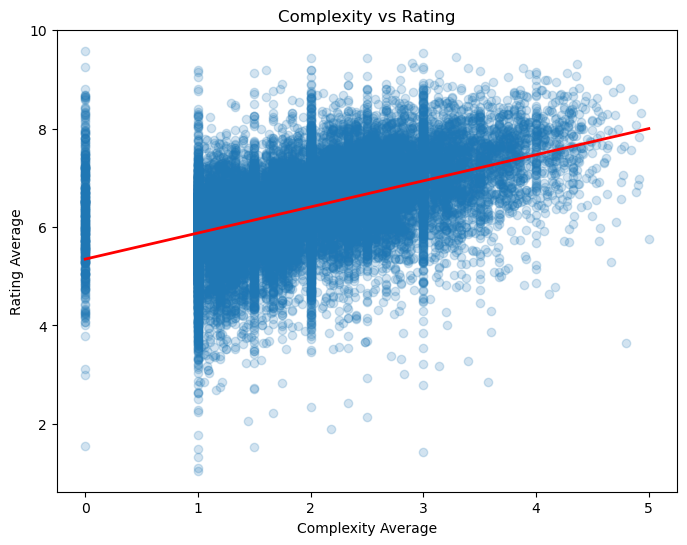

In [10]:
# 4.1 Relationship between Complexity and Rating

x = bgg_df["complexity_average"]
y = bgg_df["rating_average"]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.2)

# Trend line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_sorted = np.sort(x)
plt.plot(x_sorted, p(x_sorted), color="red", linewidth=2)

plt.xlabel("Complexity Average")
plt.ylabel("Rating Average")
plt.title("Complexity vs Rating")
plt.show()

In [11]:
# Correlation between complexity and rating
corr_value = bgg_df["complexity_average"].corr(bgg_df["rating_average"])

if corr_value < 0.1:
    interpretation = "Very weak relationship"
elif corr_value < 0.3:
    interpretation = "Weak relationship"
elif corr_value < 0.6:
    interpretation = "Moderate positive relationship"
elif corr_value < 0.8:
    interpretation = "Strong positive relationship"
else:
    interpretation = "Very strong positive relationship"

print(f"Correlation between complexity and rating: {corr_value:.2f}")
print(f"Interpretation: {interpretation}")

Correlation between complexity and rating: 0.48
Interpretation: Moderate positive relationship


### 4.2 Complexity vs Popularity

This section examines whether more complex games also achieve stronger market popularity, using **owned_users** as the main measure of popularity.

A raw scatter plot is shown first, but popularity is highly skewed because a small number of games have extremely large ownership counts. To reduce the influence of these extreme values, a second chart applies a **log scale** to popularity. Comparing the two views gives a more balanced interpretation of the relationship.

This part is important because a game may be highly rated without necessarily becoming widely owned. In other words, complexity may be rewarded in evaluations but not always in broad market reach.

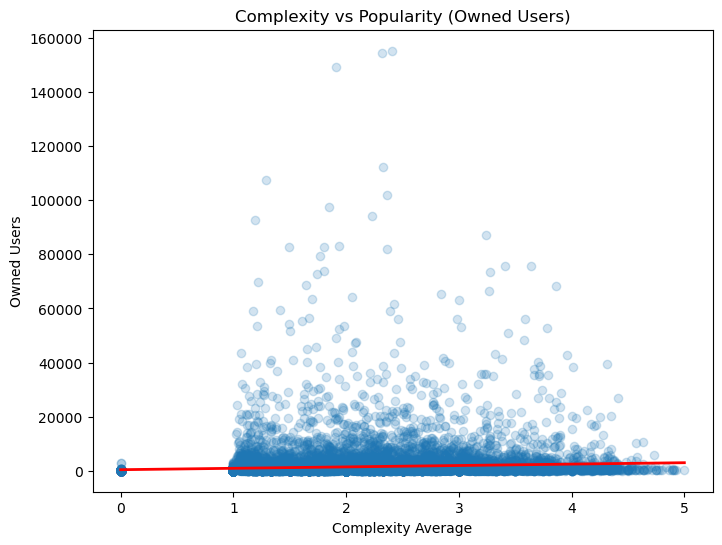

In [12]:
# 4.2.1 Relationship between Complexity and Popularity (Owned Users)

bgg_pop = bgg_df.dropna(subset=["owned_users"]).copy()

x = bgg_pop["complexity_average"]
y = bgg_pop["owned_users"]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.2)

# Trend line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_sorted = np.sort(x)
plt.plot(x_sorted, p(x_sorted), color="red", linewidth=2)

plt.xlabel("Complexity Average")
plt.ylabel("Owned Users")
plt.title("Complexity vs Popularity (Owned Users)")
plt.show()

In [13]:
# Correlation between complexity and popularity (owned users)
corr_value = bgg_pop["complexity_average"].corr(bgg_pop["owned_users"])

if corr_value < 0.1:
    interpretation = "Very weak relationship"
elif corr_value < 0.3:
    interpretation = "Weak relationship"
elif corr_value < 0.6:
    interpretation = "Moderate positive relationship"
elif corr_value < 0.8:
    interpretation = "Strong positive relationship"
else:
    interpretation = "Very strong positive relationship"

print(f"Correlation between complexity and popularity: {corr_value:.2f}")
print(f"Interpretation: {interpretation}")

Correlation between complexity and popularity: 0.09
Interpretation: Very weak relationship


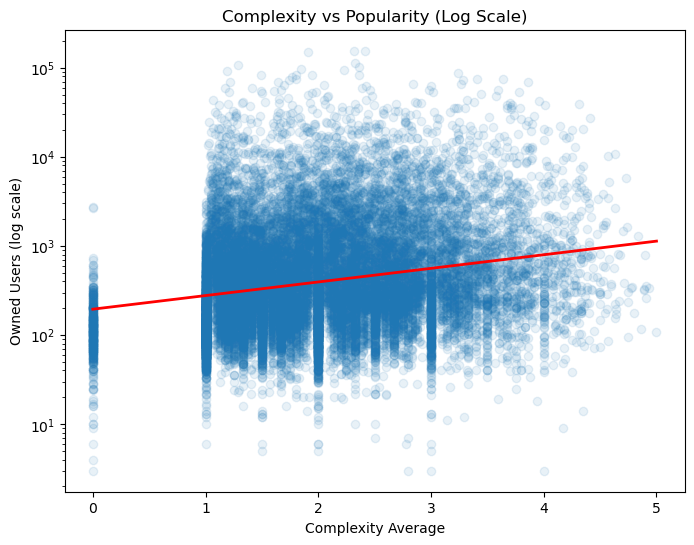

In [14]:
# 4.2.2 Relationship between Complexity and Popularity (Log Scale)

# Remove zero values for log transformation
bgg_pop_log = bgg_pop[bgg_pop["owned_users"] > 0].copy()

x = bgg_pop_log["complexity_average"]
y_log = np.log(bgg_pop_log["owned_users"])

plt.figure(figsize=(8, 6))
plt.scatter(bgg_pop_log["complexity_average"], bgg_pop_log["owned_users"], alpha=0.1)
plt.yscale("log")

# Trend line based on logged values
z = np.polyfit(x, y_log, 1)
p = np.poly1d(z)
x_sorted = np.sort(x)
plt.plot(x_sorted, np.exp(p(x_sorted)), color="red", linewidth=2)

plt.xlabel("Complexity Average")
plt.ylabel("Owned Users (log scale)")
plt.title("Complexity vs Popularity (Log Scale)")
plt.show()

In [15]:
# Correlation between complexity and log popularity
corr_value = bgg_pop_log["complexity_average"].corr(np.log(bgg_pop_log["owned_users"]))

if corr_value < 0.1:
    interpretation = "Very weak relationship"
elif corr_value < 0.3:
    interpretation = "Weak relationship"
elif corr_value < 0.6:
    interpretation = "Moderate positive relationship"
elif corr_value < 0.8:
    interpretation = "Strong positive relationship"
else:
    interpretation = "Very strong positive relationship"

print(f"Correlation between complexity and log popularity: {corr_value:.2f}")
print(f"Interpretation: {interpretation}")

Correlation between complexity and log popularity: 0.22
Interpretation: Weak relationship


### 4.3 Complexity Group Analysis

To complement the scatter plots, games are grouped into **low**, **medium**, and **high** complexity levels.

This makes it easier to compare the distribution of ratings and popularity across broader categories rather than individual games. The grouped analysis helps show whether the earlier patterns remain visible once the data are simplified into more interpretable levels.

In particular, this section checks whether higher-complexity games consistently receive stronger ratings and whether any popularity pattern remains visible after reducing the influence of individual outliers.

In [16]:
# 4.3 Create complexity groups

bins = [0, 2, 3, 5]
labels = ["Low", "Medium", "High"]

bgg_pop["complexity_group"] = pd.cut(
    bgg_pop["complexity_average"],
    bins=bins,
    labels=labels
)

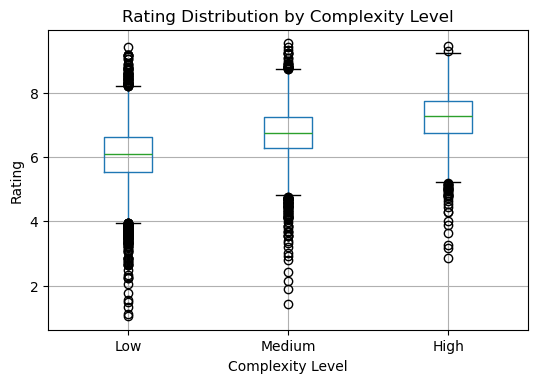

In [17]:
# 4.3.1 Rating distribution by complexity group

ax = bgg_pop.boxplot(column="rating_average", by="complexity_group", figsize=(6, 4))

plt.title("Rating Distribution by Complexity Level")
plt.suptitle("")
plt.xlabel("Complexity Level")
plt.ylabel("Rating")
plt.show()

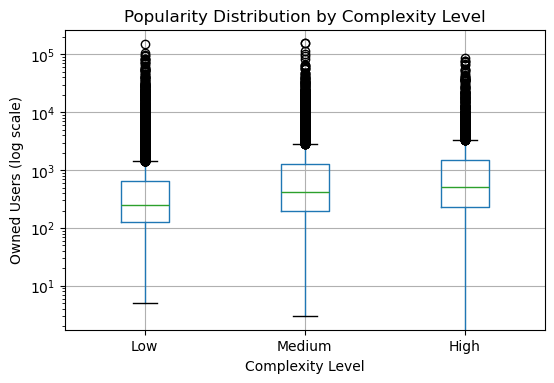

In [18]:
# 4.3.2 Popularity distribution by complexity group (log scale)

ax = bgg_pop.boxplot(column="owned_users", by="complexity_group", figsize=(6, 4))

plt.yscale("log")
plt.title("Popularity Distribution by Complexity Level")
plt.suptitle("")
plt.xlabel("Complexity Level")
plt.ylabel("Owned Users (log scale)")
plt.show()

### 4.4 Identifying a Practical Complexity Range

To move beyond broad categories, this section divides complexity into narrower ranges and compares both ratings and popularity together.

Two summary measures are used deliberately:

- **average rating**, because ratings are relatively stable  
- **median popularity**, because popularity is highly skewed and the median is less affected by extreme values  

This section is intended to identify whether there is a **practical range of complexity** that combines relatively strong user ratings with solid popularity, rather than simply asking whether “more complexity is always better”.

In [19]:
# 4.4 Identifying a Practical Complexity Range

# Create narrower complexity ranges
bins = [0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
labels = ["0–1.5", "1.5–2.0", "2.0–2.5", "2.5–3.0", "3.0–3.5", "3.5–4.0", "4.0–5.0"]

bgg_pop["complexity_range"] = pd.cut(
    bgg_pop["complexity_average"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Summary table for each complexity range
complexity_summary = bgg_pop.groupby("complexity_range", observed=True).agg(
    average_rating=("rating_average", "mean"),
    median_popularity=("owned_users", "median"),
    game_count=("name", "count")
)

display(complexity_summary)

,average_rating,median_popularity,game_count
complexity_range,,,
0–1.5,5.896375,215.0,7056
1.5–2.0,6.304046,284.0,4706
2.0–2.5,6.636675,439.0,3350
2.5–3.0,6.860354,393.0,2794
3.0–3.5,7.086245,499.0,1374
3.5–4.0,7.343329,519.5,718
4.0–5.0,7.562050,582.0,322


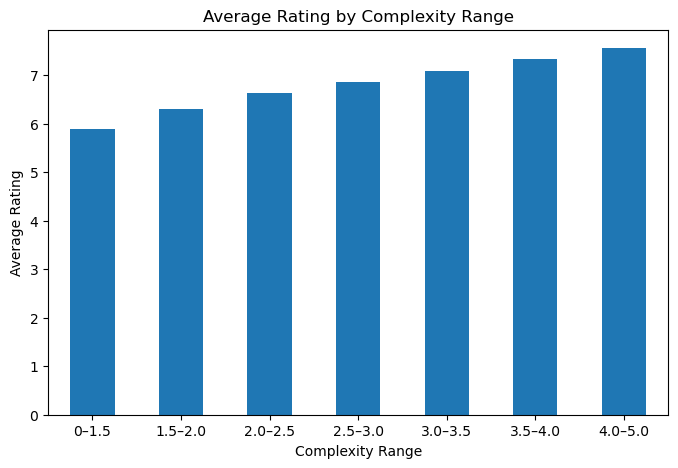

In [20]:
# Average rating by complexity range

plt.figure(figsize=(8, 5))
complexity_summary["average_rating"].plot(kind="bar")

plt.xlabel("Complexity Range")
plt.ylabel("Average Rating")
plt.title("Average Rating by Complexity Range")
plt.xticks(rotation=0)
plt.show()

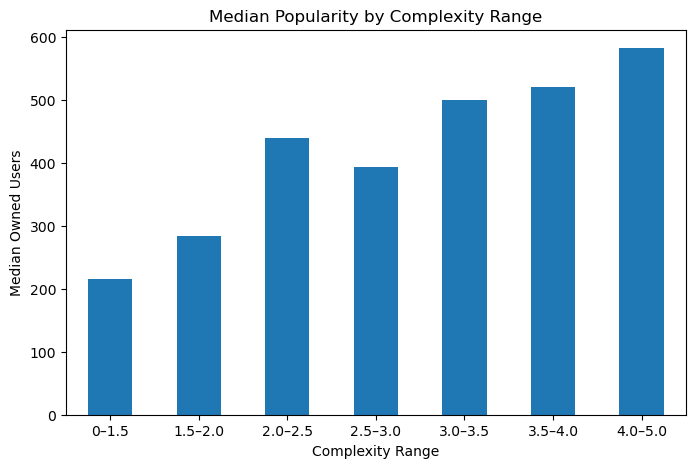

In [21]:
# Median popularity by complexity range

plt.figure(figsize=(8, 5))
complexity_summary["median_popularity"].plot(kind="bar")

plt.xlabel("Complexity Range")
plt.ylabel("Median Owned Users")
plt.title("Median Popularity by Complexity Range")
plt.xticks(rotation=0)
plt.show()

## Final Conclusion

The notebook provides three main findings.

First, **complexity and rating show a moderate positive relationship**, suggesting that more complex games are often evaluated more favourably by users.

Second, **complexity and popularity show a weaker relationship**. More complex games are not automatically more popular, especially when popularity is measured at the level of individual games.

Third, when games are grouped into broader and narrower complexity ranges, a more nuanced pattern appears. Ratings tend to rise as complexity increases, while popularity shows only a mild and uneven upward tendency. This suggests that complexity may improve perceived quality, but it does not guarantee broad market appeal.

A limitation of this analysis is that it identifies associations rather than causal effects. In addition, popularity is measured using platform-based indicators, which may not fully represent the wider board game market.

Overall, the results do not support the idea that “more complexity always leads to stronger market success”. Instead, they suggest that complexity may be most valuable within a **practical middle-to-high range**, where games can still achieve strong ratings without becoming too niche for the wider market.

These findings can support an interactive tool that helps users compare board games across different complexity levels and identify a practical balance between challenge, rating, and popularity.

In [22]:
# Save cleaned dataset for the Streamlit app

app_data = bgg_df.copy()

columns_needed = [
    'name',
    'year_published',
    'min_players',
    'max_players',
    'play_time',
    'min_age',
    'users_rated',
    'rating_average',
    'bgg_rank',
    'complexity_average',
    'owned_users',
    'mechanics'
]

app_data = app_data[columns_needed]

app_data = app_data.dropna(subset=['name', 'complexity_average', 'rating_average', 'owned_users'])

app_data.to_csv('bgg_cleaned.csv', index=False)

print("Cleaned file saved as bgg_cleaned.csv")
print("Shape:", app_data.shape)
app_data.head()

Cleaned file saved as bgg_cleaned.csv
Shape: (20320, 12)


,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics
0,Gloomhaven,2017.0,1,4,120,14,42055,8.79,1,3.86,68323.0,"Action Queue, Action Retrieval, Campaign / Bat..."
1,Pandemic Legacy: Season 1,2015.0,2,4,60,13,41643,8.61,2,2.84,65294.0,"Action Points, Cooperative Game, Hand Manageme..."
2,Brass: Birmingham,2018.0,2,4,120,14,19217,8.66,3,3.91,28785.0,"Hand Management, Income, Loans, Market, Networ..."
3,Terraforming Mars,2016.0,1,5,120,12,64864,8.43,4,3.24,87099.0,"Card Drafting, Drafting, End Game Bonuses, Han..."
4,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,8.70,5,4.22,16831.0,"Action Drafting, Area Majority / Influence, Ar..."


In [23]:
app_data.to_csv('bgg_cleaned.csv', index=False)